In [1]:
!uv pip freeze

contourpy==1.3.2
cycler==0.12.1
fonttools==4.63.0
joblib==1.5.3
kiwisolver==1.5.0
matplotlib==3.10.9
numpy==2.2.6
packaging==26.2
pillow==12.3.0
pyparsing==3.3.2
python-dateutil==2.9.0.post0
scikit-learn==1.7.2
scipy==1.15.3
six==1.17.0
threadpoolctl==3.6.0


Using Python 3.10.20 environment at: d:\Ai engineering course\.venv


In [57]:
import sys
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
sys.path.append(r"D:\Ai engineering course\datasets")     # 60 hand-written reviews
from review_data import make_reviews
from sklearn.feature_extraction.text import TfidfVectorizer
from review_data import make_reviews          # 60 hand-written reviews
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score


In [58]:
# BUILD THE DATASET: four tiny reviews
reviews = [
    "the food was great and the service was great",
    "terrible food and slow service",
    "great service will visit again",
    "the food was cold and terrible",
]


In [59]:

cv = CountVectorizer()
counts = cv.fit_transform(reviews)
print(cv.get_feature_names_out())      # the vocabulary
print(pd.DataFrame(counts.toarray(), columns=cv.get_feature_names_out()))

['again' 'and' 'cold' 'food' 'great' 'service' 'slow' 'terrible' 'the'
 'visit' 'was' 'will']
   again  and  cold  food  great  service  slow  terrible  the  visit  was  \
0      0    1     0     1      2        1     0         0    2      0    2   
1      0    1     0     1      0        1     1         1    0      0    0   
2      1    0     0     0      1        1     0         0    0      1    0   
3      0    1     1     1      0        0     0         1    1      0    1   

   will  
0     0  
1     0  
2     1  
3     0  


In [60]:

texts, labels = make_reviews()  


In [61]:


texts, labels = make_reviews()               # 1 = positive, 0 = negative

# text -> numbers -> decision, all in ONE pipeline (Day 18 habit)
model = make_pipeline(CountVectorizer(), LogisticRegression(max_iter=1000))
print(cross_val_score(model, texts, labels, cv=5).mean())   # 1.000

model.fit(texts, labels)

        # NEGATIVE

1.0


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('countvectorizer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [62]:
print(model.predict(["the momo was delicious and the staff were kind"]))   # POSITIVE
print(model.predict(["cold food, rude waiter and a long wait"]) ) 

[1]
[0]


In [63]:
reviews

['the food was great and the service was great',
 'terrible food and slow service',
 'great service will visit again',
 'the food was cold and terrible']

In [64]:
tfv = TfidfVectorizer()
transformed = tfv.fit_transform(reviews)
#dir(transformed)

#tfv.get_feature_names_out()


"""
reviews = [
    "the food was great and the service was great",
    "terrible food and slow service",
    "great service, will visit again",
    "the food was cold and terrible",
]



"""

print(pd.DataFrame(transformed.toarray(), columns=tfv.get_feature_names_out()))

      again       and      cold      food     great   service      slow  \
0  0.000000  0.216632  0.000000  0.216632  0.535167  0.216632  0.000000   
1  0.000000  0.378499  0.000000  0.378499  0.000000  0.378499  0.592992   
2  0.498197  0.000000  0.000000  0.000000  0.392784  0.317993  0.000000   
3  0.000000  0.332748  0.521314  0.332748  0.000000  0.000000  0.000000   

   terrible       the     visit       was      will  
0  0.000000  0.535167  0.000000  0.535167  0.000000  
1  0.467522  0.000000  0.000000  0.000000  0.000000  
2  0.000000  0.000000  0.498197  0.000000  0.498197  
3  0.411010  0.411010  0.000000  0.411010  0.000000  


In [65]:
print(tfv.get_params())
print(tfv.idf_)
print(transformed.toarray()[0])

{'analyzer': 'word', 'binary': False, 'decode_error': 'strict', 'dtype': <class 'numpy.float64'>, 'encoding': 'utf-8', 'input': 'content', 'lowercase': True, 'max_df': 1.0, 'max_features': None, 'min_df': 1, 'ngram_range': (1, 1), 'norm': 'l2', 'preprocessor': None, 'smooth_idf': True, 'stop_words': None, 'strip_accents': None, 'sublinear_tf': False, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'tokenizer': None, 'use_idf': True, 'vocabulary': None}
[1.91629073 1.22314355 1.91629073 1.22314355 1.51082562 1.22314355
 1.91629073 1.51082562 1.51082562 1.91629073 1.51082562 1.91629073]
[0.         0.21663198 0.         0.21663198 0.53516719 0.21663198
 0.         0.         0.53516719 0.         0.53516719 0.        ]


In [72]:
texts, labels = make_reviews()               # 1 = positive, 0 = negative

models = {
    "Logistic" : make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)),
    "Neural"   : make_pipeline(TfidfVectorizer(), MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42)),
    "Forest"   : make_pipeline(TfidfVectorizer(), RandomForestClassifier(n_estimators=100, random_state=42))
}

for name, model in models.items():
    
    cv_score = cross_val_score(model, texts, labels, cv=5).mean()
    
    print(f"--- {name} (CV Accuracy: {cv_score:.4f}) ---")
    
    model.fit(texts, labels)
    print( model.predict(["dal"]))             
    print( model.predict(["The food was not good"])) 
    print()



--- Logistic (CV Accuracy: 1.0000) ---
[0]
[1]

--- Neural (CV Accuracy: 0.9833) ---
[1]
[0]

--- Forest (CV Accuracy: 0.9500) ---
[0]
[1]



In [53]:
labels

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [56]:

POSITIVE = [
    "the food was good and the service was fast",
    "good food and very friendly staff",
    "great service and great value for money",
    "the momo was delicious and the staff were friendly",
    "delicious food, fast service, good price",
    "excellent food and excellent service",
    "the curry was delicious and the staff was kind",
    "friendly staff and fresh food",
    "fresh ingredients and good flavour",
    "the dal bhat was delicious and hot",
    "good value and the service was quick",
    "quick service and delicious coffee",
    "the staff was friendly and the food was fresh",
    "great flavour and a clean place",
    "clean tables and very good food",
    "the thukpa was excellent and hot",
    "excellent value, the food was fresh",
    "we loved the food, service was fast",
    "the biryani was delicious and the portion was generous",
    "generous portion and good price",
    "the tea was good and the staff smiled",
    "friendly waiter and delicious pastries",
    "the food arrived hot and fresh",
    "hot food, fast service, friendly staff",
    "very good experience, we will come again",
    "the chef was great and the food was delicious",
    "great place, clean and friendly",
    "the salad was fresh and the service was good",
    "good coffee and a quick, friendly staff",
    "delicious flavour and excellent price",

    "the pizza was delicious and the service was quick",
    "the noodles were fresh and tasty",
    "the restaurant was clean and comfortable",
    "the staff were polite and helpful",
    "the food was hot and delicious",
    "excellent taste and friendly service",
    "the soup was warm and flavorful",
    "great food at a reasonable price",
    "the portions were large and satisfying",
    "the waiter was polite and friendly",
    "fresh food and excellent service",
    "the restaurant had a nice atmosphere",
    "the coffee was fresh and delicious",
    "the chicken was juicy and flavorful",
    "the rice was perfectly cooked",
    "the vegetables were fresh and tasty",
    "the service was quick and professional",
    "very tasty food and good service",
    "the staff were welcoming and kind",
    "the food quality was excellent",
    "the restaurant was clean and peaceful",
    "the prices were reasonable and fair",
    "the meal was fresh and hot",
    "the waiter was helpful and polite",
    "the food was flavorful and fresh",
    "great taste and excellent presentation",
    "the portion size was generous",
    "the service was excellent and quick",
    "the food was worth the price",
    "we enjoyed the meal very much",
    "the restaurant was comfortable and clean",
    "the staff made us feel welcome",
    "the food tasted fresh and delicious",
    "the soup was delicious and hot",
    "the chicken curry was excellent",
    "the noodles were hot and flavorful",
    "the momo was fresh and tasty",
    "the biryani was hot and delicious",
    "the coffee tasted great",
    "the tea was fresh and hot",
    "the pastries were delicious and fresh",
    "the salad was crisp and fresh",
    "the service was friendly and fast",
    "the staff were attentive and polite",
    "the restaurant had excellent service",
    "the food was delicious for the price",
    "good portions and great flavour",
    "fresh food at a good price",
    "friendly staff and quick service",
    "clean restaurant and tasty food",
    "excellent meal and friendly staff",
    "we had a great experience",
    "the food was cooked perfectly",
    "the meal was hot and satisfying",
    "the flavors were rich and delicious",
    "the ingredients tasted fresh",
    "the restaurant looked clean",
    "the staff were very welcoming",
    "the service was smooth and fast",
    "the food came quickly and hot",
    "the portion was big and tasty",
    "good atmosphere and great food",
    "excellent coffee and friendly staff",
    "the tea was delicious and warm",
    "the curry was rich and flavorful",
    "the soup was fresh and tasty",
    "the rice was hot and delicious",
    "the chicken was tender and tasty",
    "the food was fresh and well cooked",
    "the waiter provided excellent service",
    "the restaurant was bright and clean",
    "the staff were helpful and friendly",
    "the prices were good for the quality",
    "the food was tasty and affordable",
    "quick service and fresh ingredients",
    "delicious meal and clean tables",
    "the place was comfortable and welcoming",
    "the food was excellent and affordable",
    "we enjoyed the friendly service",
    "the portions were generous and tasty",
    "the meal was delicious and fresh",
    "great service and delicious food",
    "the restaurant was clean and modern",
    "the staff were kind and professional",
    "the food arrived quickly and hot",
    "excellent taste and reasonable price",
    "the curry was hot and delicious",
    "the momo tasted fresh and delicious",
    "the thukpa was flavorful and warm",
    "the biryani had great flavor",
    "the coffee was strong and delicious",
    "the pastries were fresh and tasty",
    "the salad was healthy and fresh",
    "the food was satisfying and delicious",
    "the service was fast and friendly",
    "the restaurant offered good value",
    "the staff were smiling and helpful",
    "the meal was fresh and flavorful",
    "the food was nicely prepared",
    "the place was clean and pleasant",
    "the service was polite and efficient",
    "the food was delicious and affordable",
    "the portions were excellent for the price",
    "we really enjoyed the food",
    "the restaurant had a pleasant atmosphere",
    "the waiter was friendly and attentive",
    "the food was hot and perfectly cooked",
    "fresh vegetables and delicious food",
    "good coffee and friendly service",
    "excellent curry and fresh rice",
    "delicious momo and quick service",
    "great thukpa and friendly staff",
    "tasty biryani and generous portion",
    "hot tea and excellent service",
    "fresh pastries and good coffee",
    "clean tables and friendly staff",
    "good food and reasonable prices",
    "the service was quick and helpful",
    "the food quality was very good",
    "the restaurant was neat and clean",
    "the meal was excellent and filling",
    "the staff were respectful and kind",
    "the food had wonderful flavor",
    "the portion was enough for everyone",
    "the price was fair for the meal",
    "the food was fresh and delicious",
    "the service was professional and fast",
    "we will definitely visit again",
    "we had a wonderful dining experience",
    "everything was fresh and tasty",
    "everything was clean and organized",
    "the restaurant was peaceful and nice",
    "the staff gave excellent service",
    "the meal was worth every rupee",
    "great food and great atmosphere",
    "excellent quality and friendly staff",
    "the food was flavorful and hot",
    "the restaurant was very welcoming",
    "the service exceeded our expectations",
    "the food was better than expected",
    "we were happy with the service",
    "the meal was fresh and well presented",
    "the staff were quick to help",
    "the food tasted homemade and fresh",
    "the restaurant offered excellent value",
    "the food was delicious and satisfying",
    "the service was fast and organized",
    "the place was clean and comfortable",
    "the staff were friendly throughout",
    "the food was hot when served",
    "the meal was tasty and affordable",
    "great portion and excellent taste",
    "fresh ingredients and friendly service",
    "delicious food and clean restaurant",
    "quick service and good portions",
    "excellent food at a fair price",
    "friendly staff and pleasant atmosphere",
    "the food was fresh and perfectly cooked",
    "the restaurant was clean and inviting",
    "the service was quick and professional",
    "the meal was delicious from start to finish",
    "the staff were kind and welcoming",
    "we loved the fresh food",
    "the price was reasonable for the quality",
    "the food was hot and flavorful",
    "excellent service and generous portions",
    "great flavor and fresh ingredients",
    "the experience was very good",
    "we enjoyed everything we ordered",
    "the restaurant deserves a good rating",
    "the food and service were excellent",
    "a clean place with delicious food",
    "a great meal at a good price",
    "friendly service and excellent food",
    "fresh food and reasonable prices",
    "quick service and delicious meals",
    "very tasty food and generous portions",
    "the restaurant was clean and friendly",
    "the staff were polite and efficient",
    "we will definitely come back",
    "the food was excellent and fresh",
    "great experience and good value",
    "delicious food and helpful staff",
    "hot food and fast service",
    "fresh ingredients and great flavor",
    "good service and clean tables",
    "excellent meal and reasonable price",
    "the staff were friendly and professional",
    "the food was tasty and fresh",
    "the atmosphere was nice and comfortable",
    "great food, good service, fair price",
    "we really enjoyed our visit",
    "the meal was fresh and delicious",
    "everything tasted excellent",
    "the food arrived hot and quickly",
    "the staff were attentive and kind",
    "good value and excellent quality",
    "the restaurant was pleasant and clean",
    "delicious food with friendly service",
    "the portions were generous and filling",
    "the food was cooked with care",
    "excellent flavor and quick service",
    "the restaurant was worth visiting",
    "good food and a pleasant experience",
    "fresh meal and excellent service",
    "the staff were wonderful and friendly",
    "the food was very satisfying",
    "great quality and affordable prices",
    "the service was excellent throughout",
    "the food was delicious and hot",
    "clean place and helpful staff",
    "we enjoyed the meal and service",
    "the restaurant had good value",
    "the food was fresh and flavorful",
    "excellent taste and generous portions",
    "the service was fast and polite",
    "friendly atmosphere and delicious food",
    "the meal was excellent and fresh",
    "good prices and tasty food",
    "the restaurant was comfortable and clean",
    "we had no complaints about the food",
    "the staff were very friendly",
    "the food was served quickly",
    "the meal was hot and fresh",
    "great service and tasty food",
    "the food was high quality",
    "good flavor and excellent portions",
    "the experience was excellent",
    "we enjoyed the fresh ingredients",
    "the place was clean and welcoming",
    "the food was delicious and the price was fair",
    "excellent service, fresh food, good price",
    "friendly staff, clean place, great food",
    "quick service, hot food, good value",
    "fresh food, good flavor, reasonable price",
    "delicious meal, friendly staff, clean restaurant",
    "great food, fast service, generous portions",
    "excellent food, excellent service, fair price",
    "hot food, fresh ingredients, friendly staff",
    "good atmosphere, clean tables, tasty food",
    "very good service and delicious food",
    "great value and excellent food",
    "friendly staff and quick service",
    "fresh food and great flavor",
    "clean place and excellent service",
    "good portions and reasonable prices",
    "delicious coffee and friendly staff",
    "excellent curry and quick service",
    "fresh momo and good service",
    "tasty thukpa and friendly staff",
    "delicious biryani and good value",
    "hot dal bhat and excellent service",
    "fresh salad and clean restaurant",
    "great tea and friendly waiter",
    "delicious pastries and good coffee",
    "we had an excellent experience",
    "we will happily visit again",
]


NEGATIVE = [
    "the food was cold and the service was slow",
    "bad food and very rude staff",
    "terrible service and bad value for money",
    "the momo was cold and the staff were rude",
    "bad food, slow service, high price",
    "terrible food and terrible service",
    "the curry was bland and the staff was rude",
    "rude staff and stale food",
    "stale ingredients and no flavour",
    "the dal bhat was cold and bland",
    "bad value and the service was slow",
    "slow service and bitter coffee",
    "the staff was rude and the food was stale",
    "no flavour and a dirty place",
    "dirty tables and very bad food",
    "the thukpa was terrible and cold",
    "terrible value, the food was stale",
    "we hated the food, service was slow",
    "the biryani was dry and the portion was tiny",
    "tiny portion and high price",
    "the tea was bad and the staff ignored us",
    "rude waiter and stale pastries",
    "the food arrived cold and late",
    "cold food, slow service, rude staff",
    "very bad experience, we will not come again",
    "the chef was careless and the food was bland",
    "bad place, dirty and unfriendly",
    "the salad was stale and the service was bad",
    "bitter coffee and a slow, rude staff",
    "no flavour and terrible price",

    "the pizza was cold and tasteless",
    "the noodles were stale and bland",
    "the restaurant was dirty and uncomfortable",
    "the staff were rude and unhelpful",
    "the food was cold and disappointing",
    "terrible taste and rude service",
    "the soup was cold and flavorless",
    "bad food at an expensive price",
    "the portions were small and disappointing",
    "the waiter was rude and careless",
    "stale food and terrible service",
    "the restaurant had a bad atmosphere",
    "the coffee was bitter and cold",
    "the chicken was dry and tasteless",
    "the rice was poorly cooked",
    "the vegetables were stale and bad",
    "the service was slow and unprofessional",
    "very bad food and poor service",
    "the staff were unfriendly and rude",
    "the food quality was terrible",
    "the restaurant was dirty and noisy",
    "the prices were too high",
    "the meal was cold and unpleasant",
    "the waiter was rude and unhelpful",
    "the food was bland and stale",
    "bad taste and poor presentation",
    "the portion size was tiny",
    "the service was terrible and slow",
    "the food was not worth the price",
    "we disliked the meal very much",
    "the restaurant was uncomfortable and dirty",
    "the staff made us feel unwelcome",
    "the food tasted stale and bad",
    "the soup was cold and tasteless",
    "the chicken curry was terrible",
    "the noodles were cold and bland",
    "the momo was stale and tasteless",
    "the biryani was dry and cold",
    "the coffee tasted terrible",
    "the tea was bitter and cold",
    "the pastries were stale and dry",
    "the salad was old and wilted",
    "the service was slow and rude",
    "the staff were careless and rude",
    "the restaurant had terrible service",
    "the food was too expensive for the quality",
    "small portions and terrible flavor",
    "stale food at a high price",
    "rude staff and slow service",
    "dirty restaurant and bad food",
    "terrible meal and unfriendly staff",
    "we had a terrible experience",
    "the food was poorly cooked",
    "the meal was cold and unsatisfying",
    "the flavors were weak and bland",
    "the ingredients tasted old",
    "the restaurant looked dirty",
    "the staff were unfriendly",
    "the service was slow and disorganized",
    "the food came late and cold",
    "the portion was small and disappointing",
    "bad atmosphere and terrible food",
    "terrible coffee and rude staff",
    "the tea was bitter and unpleasant",
    "the curry was bland and watery",
    "the soup was cold and flavorless",
    "the rice was dry and cold",
    "the chicken was tough and tasteless",
    "the food was stale and poorly cooked",
    "the waiter provided terrible service",
    "the restaurant was dirty and unpleasant",
    "the staff were rude and careless",
    "the prices were too high for the quality",
    "the food was expensive and tasteless",
    "slow service and stale ingredients",
    "bad meal and dirty tables",
    "the place was uncomfortable and dirty",
    "the food was terrible and expensive",
    "we were unhappy with the service",
    "the portions were small and bland",
    "the meal was stale and disappointing",
    "terrible service and terrible food",
    "the restaurant was dirty and outdated",
    "the staff were rude and unprofessional",
    "the food arrived cold and late",
    "bad taste and expensive price",
    "the curry was cold and bland",
    "the momo was tasteless and cold",
    "the thukpa was bland and cold",
    "the biryani had no flavor",
    "the coffee was bitter and weak",
    "the pastries were dry and stale",
    "the salad was old and dirty",
    "the food was bland and unsatisfying",
    "the service was slow and unfriendly",
    "the restaurant offered poor value",
    "the staff were rude and ignored us",
    "the meal was stale and flavorless",
    "the food was poorly prepared",
    "the place was dirty and unpleasant",
    "the service was rude and inefficient",
    "the food was expensive and disappointing",
    "the portions were tiny for the price",
    "we regretted eating here",
    "the restaurant had a terrible atmosphere",
    "the waiter was rude and inattentive",
    "the food was cold and poorly cooked",
    "stale vegetables and terrible food",
    "bad coffee and unfriendly service",
    "terrible curry and cold rice",
    "cold momo and slow service",
    "bland biryani and tiny portion",
    "cold tea and terrible service",
    "stale pastries and bad coffee",
    "dirty tables and rude staff",
    "bad food and unreasonable prices",
    "the service was slow and careless",
    "the food quality was very poor",
    "the restaurant was dirty and messy",
    "the meal was terrible and expensive",
    "the staff were rude and disrespectful",
    "the food had no flavor",
    "the portion was too small",
    "the price was too high for the meal",
    "the food was stale and cold",
    "the service was slow and unprofessional",
    "we will not visit again",
    "we had a terrible dining experience",
    "everything was stale and tasteless",
    "everything was dirty and poorly managed",
    "the restaurant was noisy and unpleasant",
    "the staff provided terrible service",
    "the meal was not worth the money",
    "bad food and terrible atmosphere",
    "terrible quality and rude staff",
    "the food was bland and cold",
    "the restaurant was not welcoming",
    "the service was worse than expected",
    "the food was disappointing",
    "we were unhappy with the food",
    "the meal was poorly presented",
    "the staff were slow to help",
    "the food tasted old and stale",
    "the restaurant offered terrible value",
    "the food was tasteless and disappointing",
    "the service was slow and confusing",
    "the place was dirty and uncomfortable",
    "the staff were unfriendly throughout",
    "the food was cold when served",
    "the meal was bland and expensive",
    "small portion and terrible taste",
    "stale ingredients and poor service",
    "bad food and dirty restaurant",
    "slow service and cold food",
    "terrible food at a high price",
    "rude staff and dirty tables",
    "the food was bland and poorly cooked",
    "the restaurant was dirty and uninviting",
    "the service was slow and careless",
    "the meal was terrible from start to finish",
    "the staff were rude and unwelcoming",
    "we disliked the food",
    "the price was unreasonable for the quality",
    "the food was cold and tasteless",
    "terrible service and tiny portions",
    "bad flavor and stale ingredients",
    "the experience was very disappointing",
    "we regretted our visit",
    "the restaurant deserves a bad rating",
    "the food and service were terrible",
    "a dirty place with bad food",
    "a terrible meal at a high price",
    "rude service and terrible food",
    "stale food and expensive prices",
    "slow service and bad meals",
    "very bland food and tiny portions",
    "the restaurant was dirty and unfriendly",
    "the staff were rude and inefficient",
    "we will never come back",
    "the food was terrible and stale",
    "bad experience and poor value",
    "tasteless food and rude staff",
    "cold food and careless service",
    "stale ingredients and bad flavor",
    "poor service and dirty tables",
    "terrible meal and expensive price",
    "the staff were rude and careless",
    "the food was bland and cold",
    "the atmosphere was bad and uncomfortable",
    "bad food, poor service, high price",
    "we really disliked our visit",
    "the meal was cold and stale",
    "everything tasted terrible",
    "the food arrived cold and very late",
    "the staff were rude and inattentive",
    "poor value and terrible quality",
    "the restaurant was unpleasant and dirty",
    "bad food with rude service",
    "the portions were tiny and disappointing",
    "the food was cooked badly",
    "terrible flavor and slow service",
    "the restaurant was not worth visiting",
    "bad food and unpleasant experience",
    "stale meal and terrible service",
    "the staff were rude and unhelpful",
    "the food was very disappointing",
    "poor quality and expensive prices",
    "the service was terrible throughout",
    "the food was cold and bland",
    "dirty place and rude staff",
    "we hated the meal and service",
    "the restaurant offered poor value",
    "the food was stale and tasteless",
    "terrible taste and tiny portions",
    "the service was slow and rude",
    "unfriendly atmosphere and bad food",
    "the meal was terrible and cold",
    "bad prices and tasteless food",
    "the restaurant was uncomfortable and dirty",
    "we had many problems with the service",
    "the food was served too slowly",
    "the meal was cold and stale",
    "terrible service and bland food",
    "the food was low quality",
    "bad flavor and small portions",
    "the experience was terrible",
    "the place was dirty and unpleasant",
    "the food was tasteless and expensive",
    "bad service and poor quality",
    "the restaurant was noisy and dirty",
    "the meal was not satisfying",
    "the staff were rude and slow",
    "the food was cold and poorly presented",
    "terrible food and terrible value",
    "the service was slow and careless",
    "the restaurant was disappointing",
    "the food was not fresh",
    "the staff ignored our requests",
    "the meal was expensive and bland",
    "the restaurant was dirty and badly maintained",
    "the food was terrible and the service was slow",
    "rude staff, cold food, high price",
    "stale food, dirty place, terrible service",
    "small portion, bad flavor, high price",
    "cold food, slow service, dirty tables",
    "bland food, rude staff, poor value",
    "terrible meal, terrible service, expensive price",
    "stale ingredients, bad taste, rude staff",
    "dirty restaurant, cold food, slow service",
    "bad coffee, rude waiter, high price",
    "terrible food, tiny portion, poor service",
    "the food was bad and the experience was worse",
]


n_count = 0
for count in NEGATIVE:
    if 'the' in count:
        n_count+=1


p_count = 0

for count in POSITIVE:
    if 'the' in count:
        p_count+=1


print(f"the in negative is {n_count}", f"the in positive is {p_count}")


the in negative is 184 the in positive is 175


Confusion Matrix Array:
[[6 0]
 [0 6]]



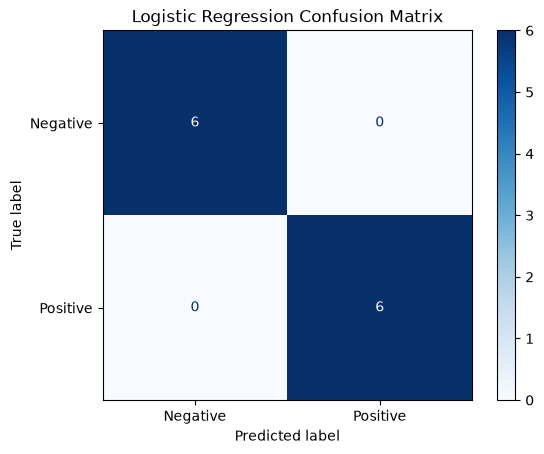

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Split data into train and test sets (crucial for a true confusion matrix)
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# 2. Extract and train your Logistic Regression pipeline
logistic_pipeline = models["Logistic"]
logistic_pipeline.fit(X_train, y_train)

# 3. Generate predictions on the test data
y_pred = logistic_pipeline.predict(X_test)

# 4. Calculate the text-based confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Array:")
print(cm)
print()

# 5. Plot and display a clean, visual confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues)

# Show the plot window
plt.title("Logistic Regression Confusion Matrix")
plt.show()
